## Comparison of ESA CCI Snow LAC and GAC data
#### Using values processed with lac_gac.py
#### Author: Elias Frey, RSGB/Unibe, 25.06.2024

### Import statements

In [13]:
import os
import warnings
import csv
import glob
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


### Functions

In [14]:
def get_coords():
    """
    Get region name and coordinate
    """
    coords_dict = {
        'usa_Alaska': [66.16, -153.37],                # Gates of the Arctic National Park, forest
        'can_Auyuittuq': [67.5, -65],                 # Auyuittuq National Park, mountains
        'chl_Rafael': [-46.76, -73,55],           # Parque Nacional Laguna San Rafael, glacier
        'nor_Jotunheim': [61.68, 7.03],           # Glacier
        'rus_Karelia': [61.82, 33.24],           # agriculture, forest
        'rus_Siberia': [63.32, 115.21],         # forest
    }

    return coords_dict

In [15]:
def get_csv_path(csv_main_dir, region):
    """
    Get csv file from directory
    """
    csv_file = glob.glob(os.path.join(path_to_csv_files, f"{region}*.csv"))[0]
    return csv_file

In [16]:
def get_csv_file(filename):
    """
    Get path of csv file for single plotting
    """
    csv_path = f'csv/{filename.split("_")[3]}_{filename.split("_")[4]}/{filename}.csv'
    return csv_path

In [17]:
def read_csv(csv_path):
    """
    Read csv file
    """
    # Initialize empty dictionary to store data
    csv_dict = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))
    
    # Read data from CSV file and populate dictionary
    with open(csv_path, 'r', newline='') as csv_file:
        reader = csv.DictReader(csv_file)
        for row in reader:
            date_str = row['date']
            platform = row['datatype']
            satellite = row['satellite']
            region = row['region']
            data_str = row['data']
            
            # Convert date string to datetime object
            date = datetime.strptime(date_str, '%Y%m%d').strftime('%d-%m-%Y')
            
            # Convert data string to list of floats, handling NaN values
            data = [np.nan if val == 'nan' else float(val) for val in data_str.strip('[]').split(',')]
            
            # Update dictionary
            csv_dict[date][platform][satellite][region] = data

    return csv_dict

In [18]:
def filter_dates(data, start_date, end_date, date_format="%d-%m-%Y"):
    """
    Filters the data dictionary to include only entries within the specified date range
    """
    start = datetime.strptime(start_date, date_format)
    end = datetime.strptime(end_date, date_format)

    filtered_data = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))

    for date_str, value in data.items():
        date = datetime.strptime(date_str, date_format)
        if start <= date <= end:
            filtered_data[date_str] = value

    return filtered_data

In [19]:
def get_regionstring(csv_path):
    country, region = os.path.basename(csv_path).split('_')[0:2]
    plot_title = f"{region.capitalize()} ({country.upper()})"
    return plot_title

In [20]:
def plot_comparison(var_dict, csv_path, plot_category, date_range):
    """
    Plot comparison of LAC and GAC with specified parameters
    """
    # Ignore NaN values warning
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN axis encountered")

    # Create empty arrays
    x = list(var_dict.keys())
    lac_noaa11_y = [np.nan] * len(x)
    gac_noaa11_y = [np.nan] * len(x)
    lac_noaa14_y = [np.nan] * len(x)
    gac_noaa14_y = [np.nan] * len(x)
    
    for i, (date, data) in enumerate(var_dict.items()):
        for platform, platform_data in data.items():
            for satellite, satellite_data in platform_data.items():
                for region, region_data in satellite_data.items():  # Iterate over regions
                    if region_data:  # Check if region data is not empty
                        max_value = np.nanmax(region_data)
                        if not np.isnan(max_value):
                            category = int(max_value / 10) * 10  # Convert max_value to category
                            if platform == 'lac' and satellite == 'noaa11':
                                if plot_category:
                                    lac_noaa11_y[i] = category
                                else:
                                    lac_noaa11_y[i] = max_value
                            elif platform == 'gac' and satellite == 'noaa11':
                                if plot_category:
                                    gac_noaa11_y[i] = category
                                else:
                                    gac_noaa11_y[i] = max_value
                            elif platform == 'lac' and satellite == 'noaa14':
                                if plot_category:
                                    lac_noaa14_y[i] = category
                                else:
                                    lac_noaa14_y[i] = max_value
                            elif platform == 'gac' and satellite == 'noaa14':
                                if plot_category:
                                    gac_noaa14_y[i] = category
                                else:
                                    gac_noaa14_y[i] = max_value
    
    

    plt.figure(figsize=(10, 6))    
    
    # Plot lines only for satellite category containig data
    if not all(i != i for i in lac_noaa11_y):
        plt.plot(x, lac_noaa11_y, label='LAC NOAA11', marker='o', linestyle='', color='#38b000')
    if not all(i != i for i in lac_noaa14_y):
        plt.plot(x, lac_noaa14_y, label='LAC NOAA14', marker='o', linestyle='', color='#31572c')
    if not all(i != i for i in gac_noaa11_y):
        plt.plot(x, gac_noaa11_y, label='GAC NOAA11', marker='o', linestyle='', color='#ffdd00')
    if not all(i != i for i in gac_noaa14_y):
        plt.plot(x, gac_noaa14_y, label='GAC NOAA14', marker='o', linestyle='', color='#ffb703')
    
    # Set plot labels and title
    plt.xlabel('')
    plt.ylabel('Snow Cover Fraction [%]')
    csv_name = get_regionstring(csv_path)
    if plot_category:
        plt.title(f'Comparison of LAC & GAC SCFG (10-stage) {csv_name} SCFG 2° × 2°')
    else:
        plt.title(f'Comparison of LAC & GAC SCFG {csv_name} SCFG 2° × 2°')
    
    # Add legend
    plt.legend()
    plt.xticks(np.arange(0, len(x), step=max(len(x)//10, 1)), rotation=45)
    plt.tight_layout()  
    plt.grid(False)  
    plt.savefig(f'plots/{date_range}/{csv_name}_SCFG_comparison_2x2_degree_{date_range}.png')
    plt.show()

In [21]:
def plot_difference(var_dict, csv_path, date_range):
    """
    Plot differences of LAC and GAC with specified parameters
    """
    # Ignore NaN values warning
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN axis encountered")

    # Create empty arrays
    x = list(var_dict.keys())
    lac_noaa11_y = [np.nan] * len(x)
    gac_noaa11_y = [np.nan] * len(x)
    lac_noaa14_y = [np.nan] * len(x)
    gac_noaa14_y = [np.nan] * len(x)
    
    for i, (date, data) in enumerate(var_dict.items()):
        for platform, platform_data in data.items():
            for satellite, satellite_data in platform_data.items():
                for region, region_data in satellite_data.items():  # Iterate over regions
                    if region_data:  # Check if region data is not empty
                        max_value = np.nanmax(region_data)
                        if not np.isnan(max_value):
                            category = int(max_value / 10) * 10  # Convert max_value to category
                            if platform == 'lac' and satellite == 'noaa11':
                                lac_noaa11_y[i] = category
                            elif platform == 'gac' and satellite == 'noaa11':
                                gac_noaa11_y[i] = category
                            elif platform == 'lac' and satellite == 'noaa14':
                                lac_noaa14_y[i] = category
                            elif platform == 'gac' and satellite == 'noaa14':
                                gac_noaa14_y[i] = category
    
    
    # Create arrays from lists
    arr1 = np.array(lac_noaa11_y)
    arr2 = np.array(gac_noaa11_y)
    arr3= np.array(lac_noaa14_y)
    arr4 = np.array(gac_noaa14_y)
    
    # Calculate differences, ignoring NaN values
    differences1 = np.where(np.isnan(arr1) | np.isnan(arr2), np.nan, arr1 - arr2)
    differences2 = np.where(np.isnan(arr3) | np.isnan(arr4), np.nan, arr3 - arr4)

    # Find valid (non-NaN) differences
    valid1 = ~np.isnan(differences1)
    valid2 = ~np.isnan(differences2)

    top10_diff1 = sorted(
    zip(np.array(x)[valid1], differences1[valid1]),
    key=lambda t: abs(t[1]),
    reverse=True
    )[:10]
    
    top10_diff2 = sorted(
        zip(np.array(x)[valid2], differences2[valid2]),
        key=lambda t: abs(t[1]),
        reverse=True
    )[:10]
    
    # Plot data
    plt.figure(figsize=(10, 6))
    
    plt.plot(x, differences1, label='LAC-GAC NOAA11', marker='.', linestyle='', color='#0077b6')
    plt.plot(x, differences2, label='LAC-GAC NOAA14', marker='.', linestyle='', color='#023e8a')
    
    # Set plot labels and title
    plt.xlabel('')
    plt.ylabel('Differences in Snow Cover Fraction [%]')
    csv_name = get_regionstring(csv_path)
    plt.title(f'Differences of LAC - GAC SCFG (10-step) {csv_name} SCFG 2° × 2°')
    
    # Add legend
    plt.legend()
    plt.xticks(np.arange(0, len(x), step=max(len(x)//10, 1)), rotation=45)
    plt.tight_layout()
    plt.grid(False)
    
    plt.savefig(f'plots/{date_range}/{csv_name}_SCFG_difference_2x2_degree_{date_range}.png')
    plt.show()

    # Print the 10 largest differences
    print(f"\nTop 10 NOAA11 LAC-GAC differences for {csv_name}:")
    for date, diff in top10_diff1:
        print(f"{date}: {diff}")
    
    print(f"\nTop 10 NOAA14 LAC-GAC differences for {csv_name}:")
    for date, diff in top10_diff2:
        print(f"{date}: {diff}")

    return top10_diff1, top10_diff2

In [22]:
def plot_difference(var_dict, csv_path, date_range):
    """
    Plot differences of LAC and GAC with specified parameters
    """
    # Ignore NaN values warning
    warnings.filterwarnings(
        "ignore",
        category=RuntimeWarning,
        message="All-NaN axis encountered"
    )

    # Create empty arrays
    x = list(var_dict.keys())
    lac_noaa11_y = [np.nan] * len(x)
    gac_noaa11_y = [np.nan] * len(x)
    lac_noaa14_y = [np.nan] * len(x)
    gac_noaa14_y = [np.nan] * len(x)

    for i, (date, data) in enumerate(var_dict.items()):
        for platform, platform_data in data.items():
            for satellite, satellite_data in platform_data.items():
                for region, region_data in satellite_data.items():
                    if region_data:
                        max_value = np.nanmax(region_data)

                        if not np.isnan(max_value):
                            category = int(max_value / 10) * 10

                            if platform == 'lac' and satellite == 'noaa11':
                                lac_noaa11_y[i] = category

                            elif platform == 'gac' and satellite == 'noaa11':
                                gac_noaa11_y[i] = category

                            elif platform == 'lac' and satellite == 'noaa14':
                                lac_noaa14_y[i] = category

                            elif platform == 'gac' and satellite == 'noaa14':
                                gac_noaa14_y[i] = category

    # Create arrays from lists
    arr1 = np.array(lac_noaa11_y)
    arr2 = np.array(gac_noaa11_y)
    arr3 = np.array(lac_noaa14_y)
    arr4 = np.array(gac_noaa14_y)

    # Calculate differences, ignoring NaN values
    differences1 = np.where(
        np.isnan(arr1) | np.isnan(arr2),
        np.nan,
        arr1 - arr2
    )

    differences2 = np.where(
        np.isnan(arr3) | np.isnan(arr4),
        np.nan,
        arr3 - arr4
    )

    # ---------------------------------------------------------
    # Print biggest positive and negative differences
    # ---------------------------------------------------------
    def print_extreme_differences(differences, label):
        valid = ~np.isnan(differences)

        if not np.any(valid):
            print(f"{label}: No valid differences")
            return

        valid_indices = np.where(valid)[0]
        valid_values = differences[valid]

        # Biggest positive difference
        max_pos = np.argmax(valid_values)
        max_pos_idx = valid_indices[max_pos]

        # Biggest negative difference
        max_neg = np.argmin(valid_values)
        max_neg_idx = valid_indices[max_neg]

        print(f"\n{label}")
        print(
            f"  Biggest positive: "
            f"{x[max_pos_idx]} = {differences[max_pos_idx]:.0f}%"
        )
        print(
            f"  Biggest negative: "
            f"{x[max_neg_idx]} = {differences[max_neg_idx]:.0f}%"
        )

    print_extreme_differences(differences1, "NOAA11 LAC-GAC")
    print_extreme_differences(differences2, "NOAA14 LAC-GAC")

    # ---------------------------------------------------------
    # Plot data
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))

    plt.plot(
        x,
        differences1,
        label='LAC-GAC NOAA11',
        marker='.',
        linestyle='',
        color='#0077b6'
    )

    plt.plot(
        x,
        differences2,
        label='LAC-GAC NOAA14',
        marker='.',
        linestyle='',
        color='#023e8a'
    )

    # Set plot labels and title
    plt.xlabel('')
    plt.ylabel('Differences in Snow Cover Fraction [%]')

    csv_name = get_regionstring(csv_path)

    plt.title(
        f'Differences of LAC - GAC SCFV (10-step) {csv_name}'
    )

    # Add legend
    plt.legend()

    plt.xticks(
        np.arange(0, len(x), step=max(len(x) // 10, 1)),
        rotation=45
    )

    plt.tight_layout()
    plt.grid(False)

    plt.savefig(
        f'plots/{date_range}/{csv_name}_SCFV_difference_{date_range}.png'
    )

    plt.show()

### User input

In [23]:
### DEFINE PLOT PARAMETERS ###

# Csv file name
path_to_csv_files = 'csv/SCFG2x2_degree/'

# Range of Plot date
start_date = '01-01-1992'
end_date = '31-12-1996'

# Comparision plots
plot_category = False               # Categorize SCF values (10-stages)
fullrange_comparison = False        # Ignores start_date and end_date for comparison plots

# Differences plots
fullrange_differences = True        # Ignores start_date and end_date for difference plots

### Plotting

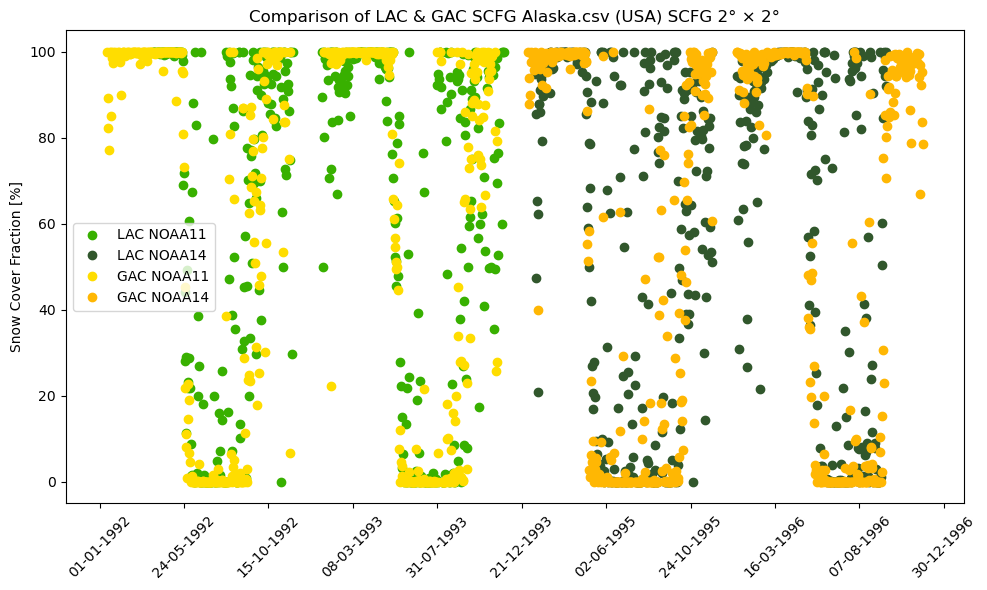


NOAA11 LAC-GAC
  Biggest positive: 12-06-1992 = 100%
  Biggest negative: 06-11-1992 = -100%

NOAA14 LAC-GAC
  Biggest positive: 24-05-1995 = 100%
  Biggest negative: 29-10-1995 = -100%


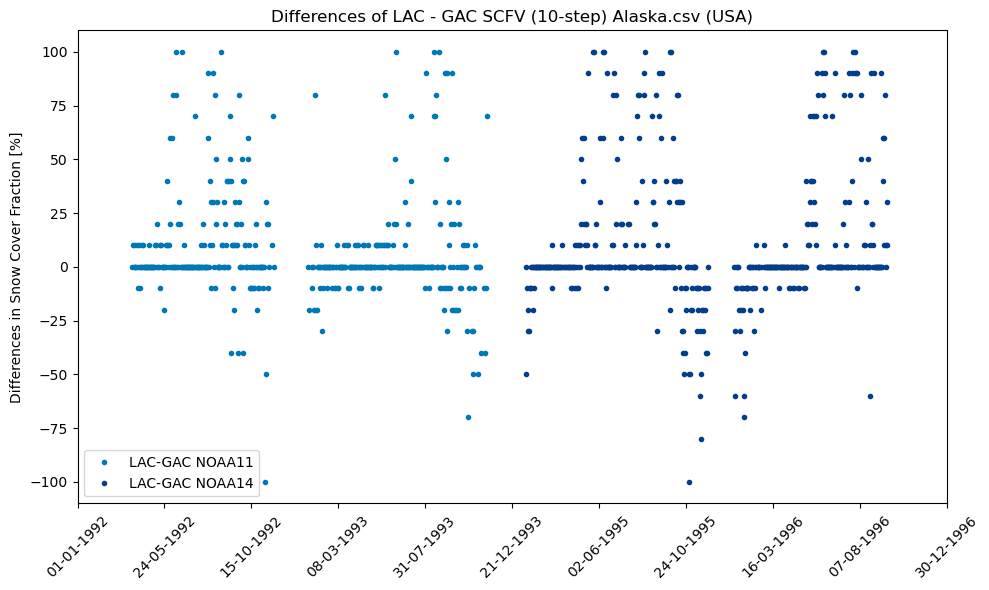

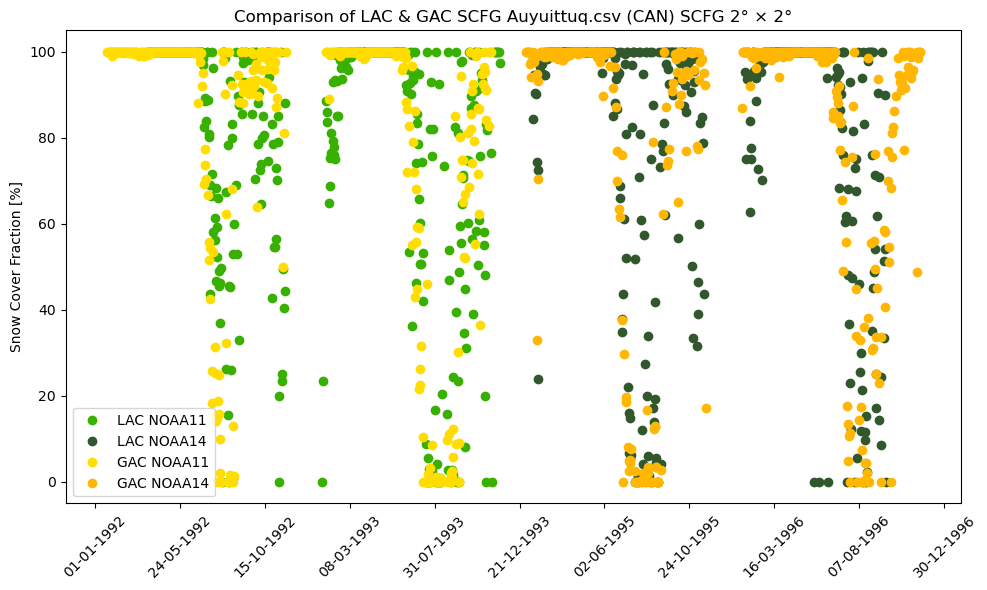


NOAA11 LAC-GAC
  Biggest positive: 22-08-1993 = 100%
  Biggest negative: 03-08-1992 = -100%

NOAA14 LAC-GAC
  Biggest positive: 11-08-1995 = 100%
  Biggest negative: 10-02-1995 = -70%


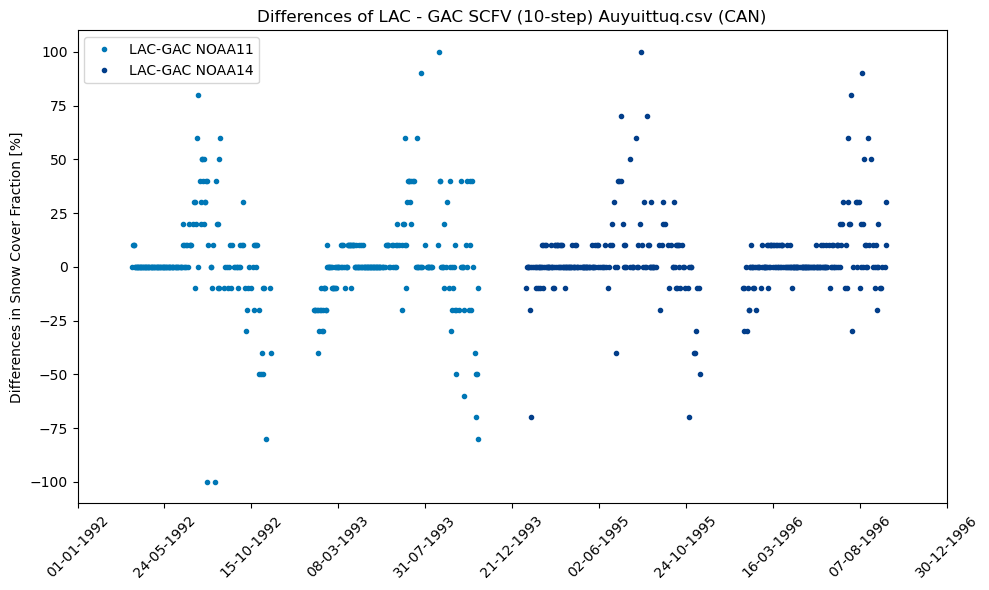

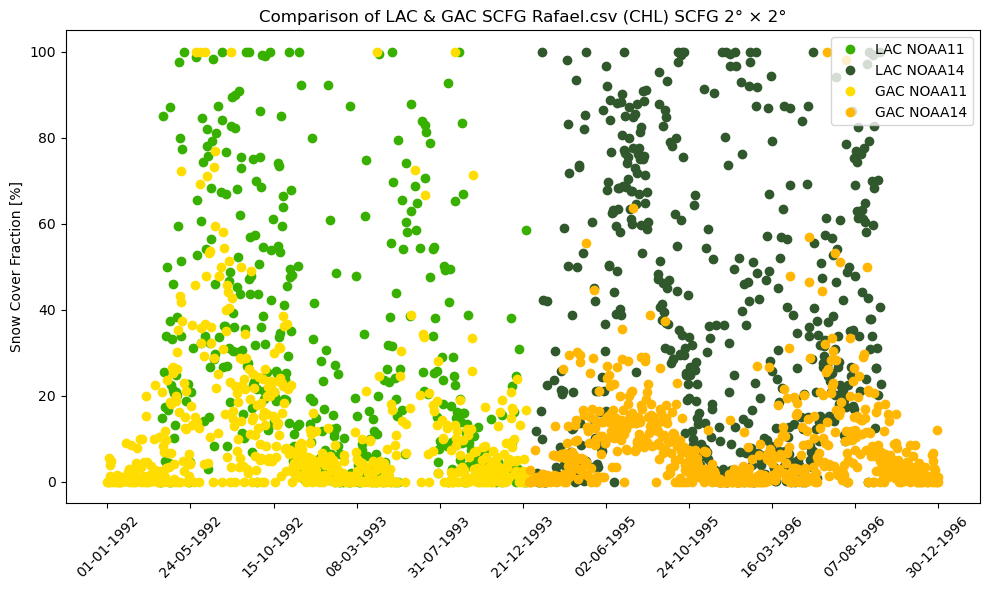


NOAA11 LAC-GAC
  Biggest positive: 02-07-1992 = 90%
  Biggest negative: 04-07-1992 = -50%

NOAA14 LAC-GAC
  Biggest positive: 11-02-1995 = 100%
  Biggest negative: 03-07-1996 = -30%


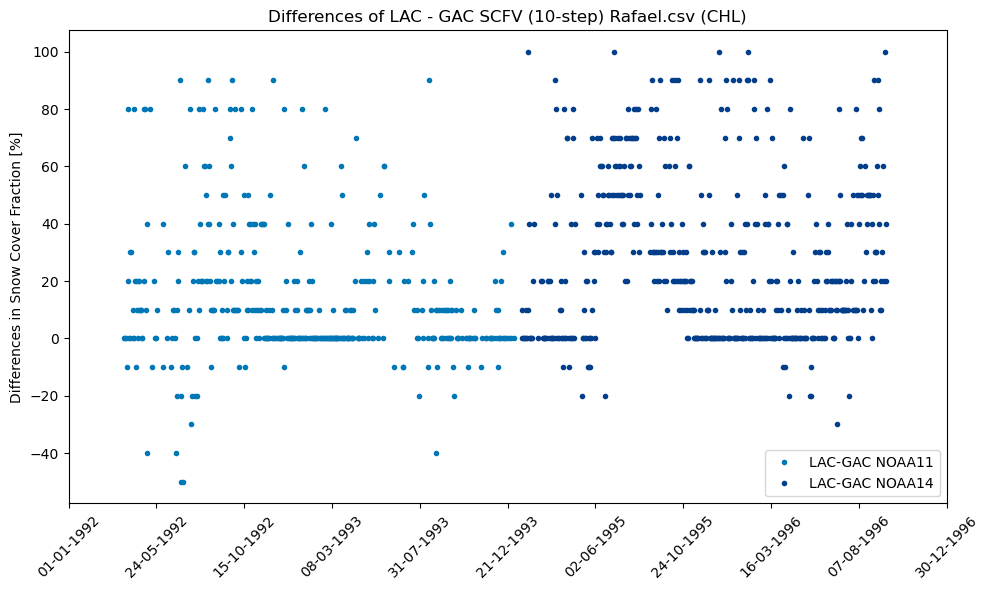

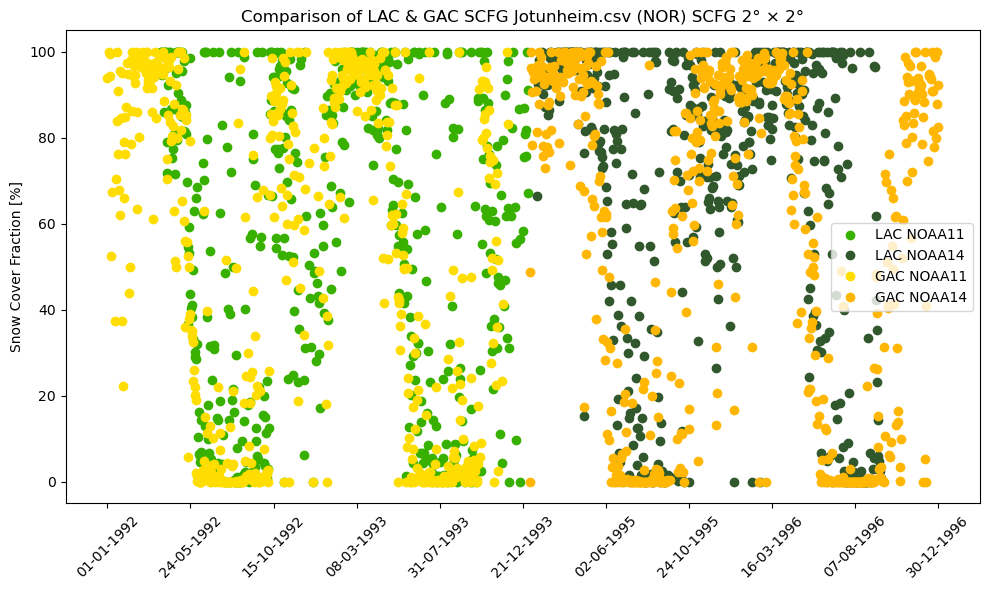


NOAA11 LAC-GAC
  Biggest positive: 13-07-1992 = 100%
  Biggest negative: 09-02-1993 = -60%

NOAA14 LAC-GAC
  Biggest positive: 30-06-1995 = 100%
  Biggest negative: 04-01-1996 = -60%


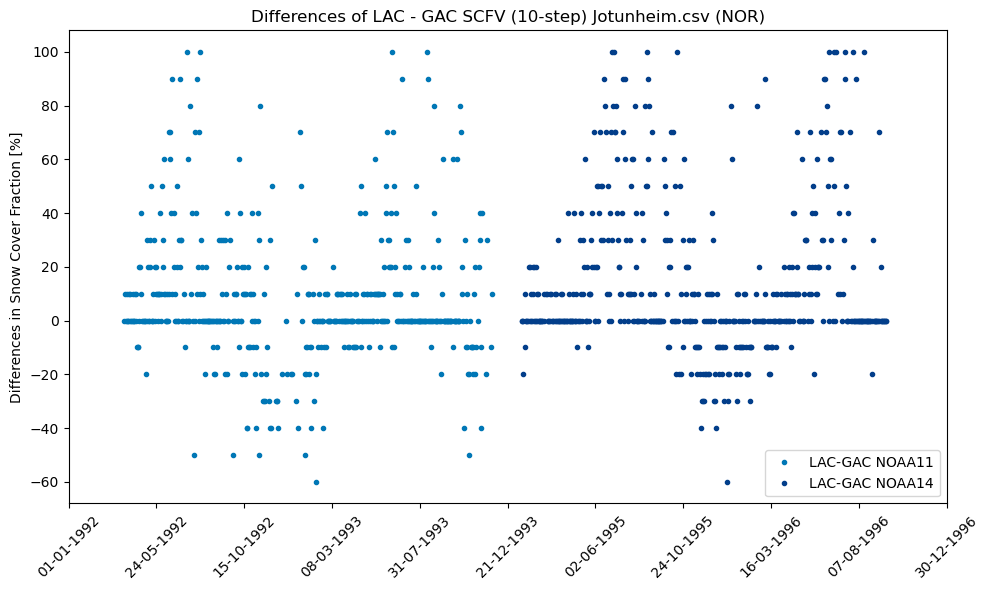

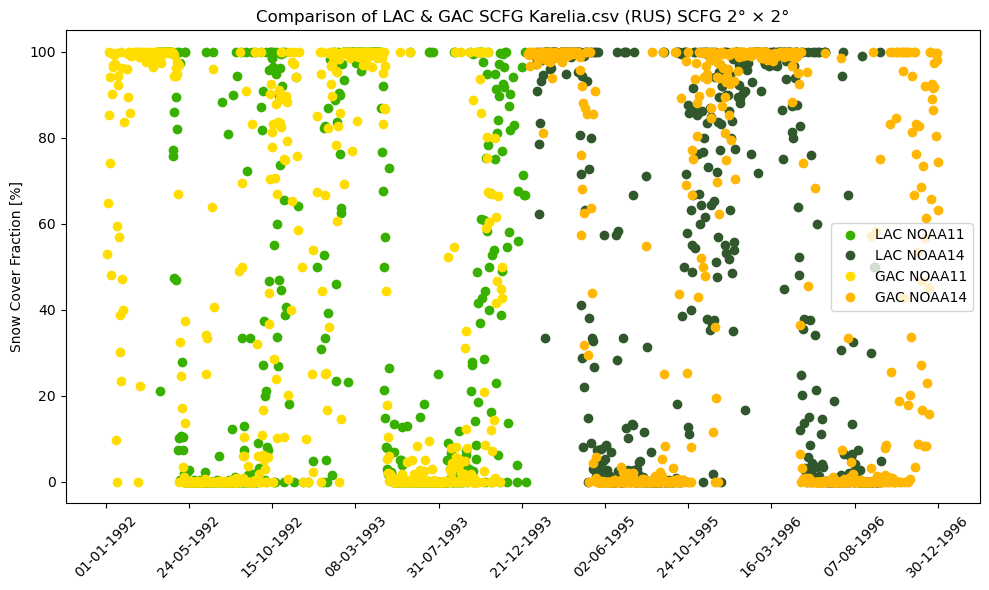


NOAA11 LAC-GAC
  Biggest positive: 14-08-1992 = 100%
  Biggest negative: 25-05-1993 = -100%

NOAA14 LAC-GAC
  Biggest positive: 21-05-1995 = 100%
  Biggest negative: 16-05-1996 = -90%


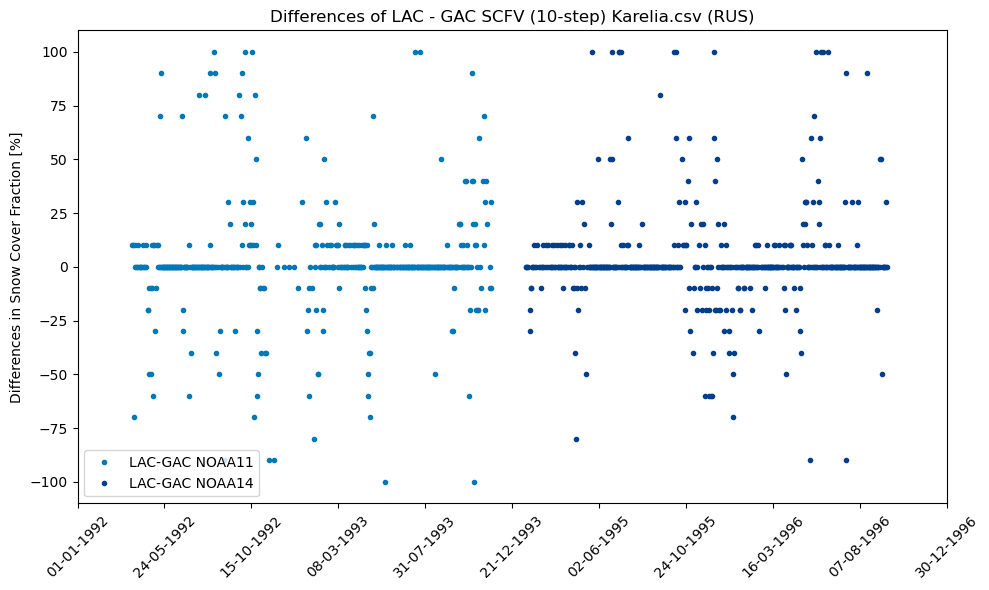

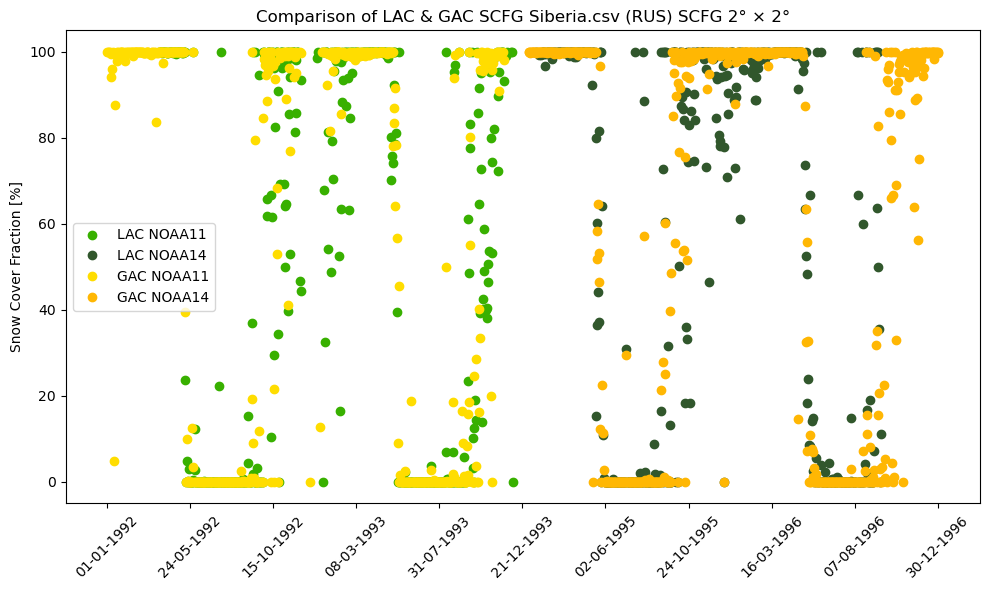


NOAA11 LAC-GAC
  Biggest positive: 25-09-1993 = 100%
  Biggest negative: 10-01-1993 = -100%

NOAA14 LAC-GAC
  Biggest positive: 11-05-1995 = 100%
  Biggest negative: 02-10-1995 = -100%


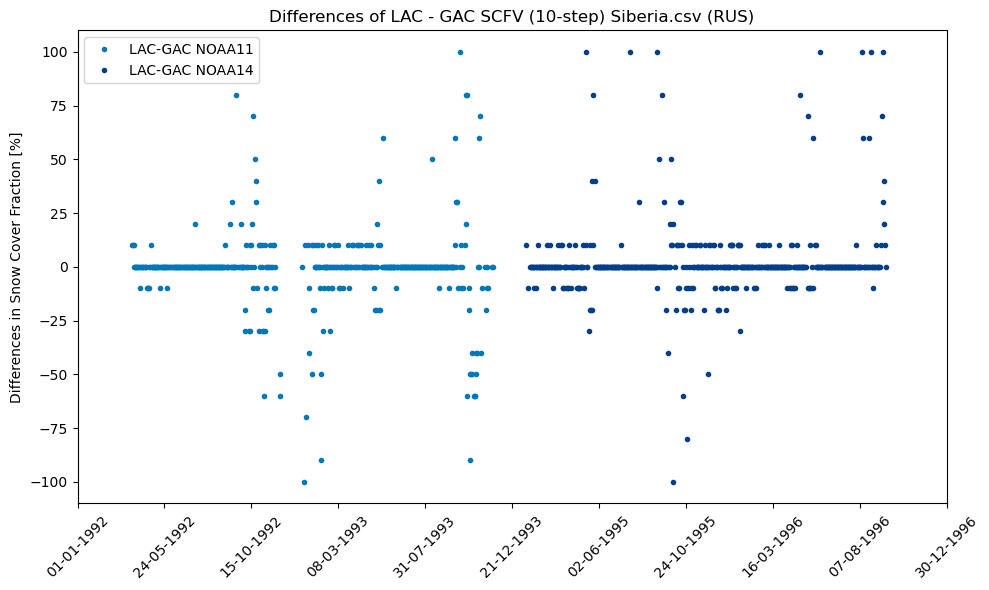

In [27]:
date_range = start_date.replace('-', '') + '_' + end_date.replace('-', '') # Create string for folder name
# Create dirs
if not os.path.isdir('plots/'):
    os.makedirs('plots/')
if not os.path.isdir(f'plots/{date_range}/'):
    os.makedirs(f'plots/{date_range}/')

for region, coords in get_coords().items():
    csv_path = get_csv_path(path_to_csv_files, region)
    csv_file = read_csv(csv_path)
    filtered_data = filter_dates(csv_file, start_date, end_date)
    # Plot
    if fullrange_comparison:
        plot_comparison(var_dict = csv_file, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
    else:
        plot_comparison(var_dict = filtered_data, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
    
    if fullrange_differences:
        plot_difference(var_dict = csv_file, csv_path = csv_path, date_range = date_range)
    else:
        plot_difference(var_dict = filtered_data, csv_path = csv_path, date_range = date_range)

### Create single plots

In [ ]:
### DEFINE PLOT PARAMETERS ###

# Csv file name
csv_filename = 'rus_Siberia_values_20260727_174204'

# Range of Plot date
start_date = '01-01-1995'
end_date = '31-12-1995'

# Comparision plots
plot_category = False               # Categorize SCF values (10-stages)
fullrange_comparison = False        # ignores start_date and end_date for comparison plots

# Differences plots
fullrange_differences = True        # ignores start_date and end_date for difference plots

In [25]:
# Define the CSV file path
csv_path = get_csv_file(csv_filename)

NameError: name 'csv_filename' is not defined

In [103]:
csv_path2 = 'csv_by_region/rus_Siberia_values_20260804_164503.csv'

In [104]:
# Read csv file
new_dict = read_csv(csv_path2)

In [105]:
# Filter data by defined time span
filtered_data = filter_dates(new_dict, start_date, end_date)

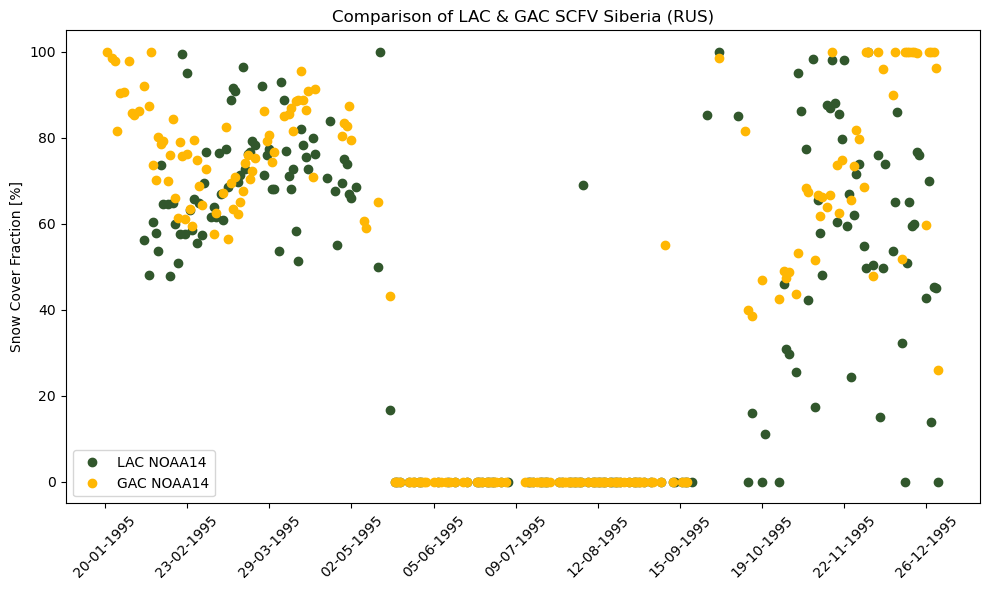

In [106]:
# Plot
if fullrange_comparison:
    plot_comparison(var_dict = new_dict, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
else:
    plot_comparison(var_dict = filtered_data, csv_path = csv_path, plot_category = plot_category, date_range=date_range)

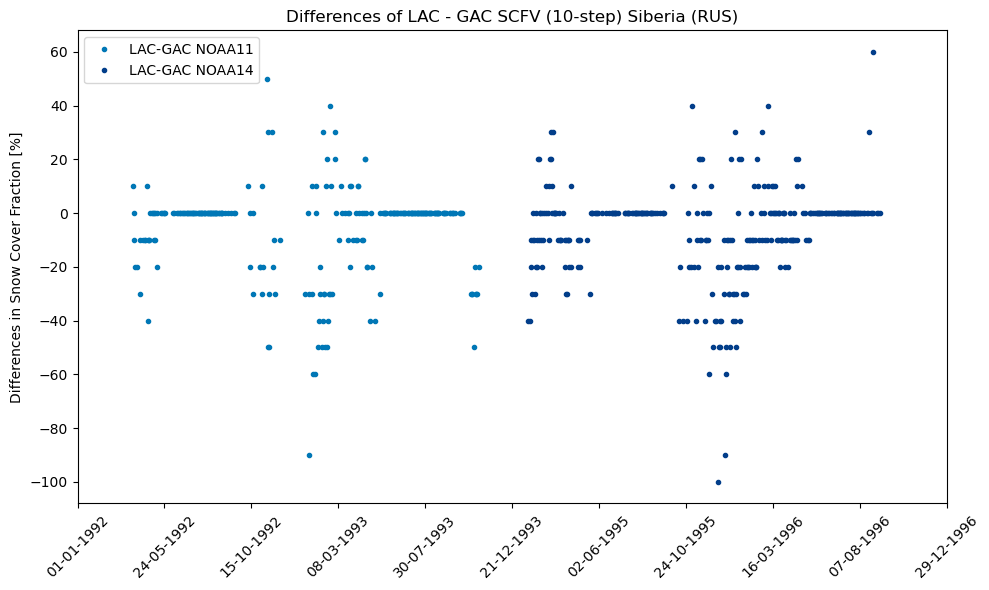

In [107]:
# Plot
if fullrange_differences:
    plot_difference(var_dict = new_dict, csv_path = csv_path, date_range=date_range)
else:
    plot_difference(var_dict = filtered_data, csv_path = csv_path, date_range=date_range)